In [48]:
import pandas as pd
import numpy as np
from scapy.utils import RawPcapReader
from scapy.layers.inet import IP, TCP, UDP, Ether
from scapy.packet import Packet
from ids_expt.core.defs import Session

### Mapping CSV to PCAP

In [49]:
from pathlib import Path

pcap_root = Path(r"E:\MSc Works\IDS\data\Total PCAP Files")
csv_root = Path(r"E:\MSc Works\IDS\data\CICFlowMeter")

pcap_files = [f.name for f in list(pcap_root.glob("*.pcap"))]
csv_files = list(csv_root.glob("*.csv"))
file_mapping = {
    "20200514_DNP3_Disable_Unsolicited_Messages_Attack_UOWM_DNP3_Dataset_Slave_05.pcap_FlowLABELED.csv": "20200508_DNP3_Disable_Unsolicited_Messages_Attack_UOWM_DNP3_Dataset_Slave_05.pcap",
    "20200518_Initialize_Data_Attack_UOWM_DNP3_Dataset_Master.pcap_FlowLABELED.csv": "20200518_Intialize_Data_Attack_UOWM_DNP3_Dataset_Master.pcap",
}

for cfile in csv_files:
    fname = cfile.stem
    if cfile.name in file_mapping:
        continue
    fname = fname.replace("_FlowLABELED", "")
    # fname = fname.replace("UOWM_", "")
    fname2 = fname.split("_")[0] + "_DNP3_" + "_".join(fname.split("_")[1:])
    found = False

    fnames = fname.split("_")
    fname3 = "_".join([f for i, f in enumerate(fnames) if i != 1])

    # 20200514_Disable_Unsolicited_Messages_Attack_UOWM_DNP3_Dataset_Attacker_01
    pcap_name = ""
    if fname in pcap_files:
        found = True
        pcap_name = fname
    elif fname2 in pcap_files:
        found = True
        pcap_name = fname2
    elif fname3 in pcap_files:
        found = True
        pcap_name = fname3
    else:
        print(f"Skipping {fname} \n {cfile.stem} as no matching pcap file found.")
        continue
    file_mapping[cfile.name] = pcap_name

In [50]:
import json


with open("cic_file_mapping.json", "w") as f:
    json.dump(file_mapping, f, indent=4)

In [51]:
from pathlib import Path
from loguru import logger
from scapy.all import Packet
from scapy.all import IP, TCP, Ether, raw
import cv2
import json
from tqdm import tqdm
from scapy.layers.inet import IP, TCP, Ether
import pickle


def stream_pcap(pcap_path):
    """Generator to yield parsed packets and their timestamps from a pcap file"""
    for pkt_data, pkt_metadata in RawPcapReader(pcap_path):
        pkt = Ether(pkt_data)
        ts = pkt_metadata.sec + pkt_metadata.usec / 1e6
        yield pkt, ts


def is_dnp3_packet(pkt):
    # Check if packet has TCP or UDP layer
    if pkt.haslayer(TCP):
        l4 = pkt[TCP]
    elif pkt.haslayer(UDP):
        l4 = pkt[UDP]
    else:
        return False

    # Check if either src or dst port is 20000 (DNP3 default port)
    if l4.sport != 20000 and l4.dport != 20000:
        return False

    # Check if payload exists and starts with DNP3 header bytes 0x05 0x64
    raw = bytes(l4.payload)
    if len(raw) >= 2 and raw[0] == 0x05 and raw[1] == 0x64:
        return True
    return False


def anonymize_packet(packet: Packet) -> Packet:
    """Anonymize packet by removing address information"""
    # Create copy to avoid modifying original packet
    pkt = packet.copy()

    # IP layer handling
    if pkt.haslayer(IP):
        pkt[IP].src = "0.0.0.0"
        pkt[IP].dst = "0.0.0.0"

    # Ethernet layer handling
    if pkt.haslayer(Ether):
        pkt[Ether].src = "00:00:00:00:00:00"
        pkt[Ether].dst = "00:00:00:00:00:00"

    # TCP layer handling
    if pkt.haslayer(TCP):
        pkt[TCP].sport = 0
        pkt[TCP].dport = 0

    return pkt


class PCAPSessionFeatureExtractor:
    def __init__(
        self,
        pcap_path: Path,
        label_df: pd.DataFrame = pd.DataFrame(),
        out_dir: Path = Path("output"),
        max_packets: int = -1,
        max_bytes: int = -1,
        max_sessions: int = -1,
    ):
        self.out_dir = out_dir
        self.max_packets = max_packets
        self.max_bytes = max_bytes
        self.pcap_path = pcap_path
        self.packet_buffer = None
        self.out_dir = Path(out_dir) / pcap_path.stem
        self.out_dir.mkdir(parents=True, exist_ok=True)
        self.sessions = []
        self.stats = None
        self.max_sessions = max_sessions
        self.label_df = label_df

    def load(self):
        """Load packets from the PCAP file."""
        logger.info(f"Loading packets from {self.pcap_path}...")
        self.packet_buffer = list(stream_pcap(str(self.pcap_path)))
        logger.info(f"Loaded {len(self.packet_buffer)} packets from {self.pcap_path}")

    def packets_to_labelled_sessions(self, packet_buffer: list[tuple[Packet, float]]):
        df = self.label_df.copy()
        sessions = []
        # packets = [(p.copy(), ts) for p, ts in packet_buffer]
        df["Start_ts"] = df["Timestamp"].apply(lambda t: t.timestamp())
        df["End_ts"] = df["Start_ts"] + df["Flow Duration"] / 1e6
        df["EndTimestamp"] = df["Timestamp"] + pd.to_timedelta(
            df["Flow Duration"], unit="us"
        )
        packet_ts = np.array([pts[1] for pts in packet_buffer])
        completed_packets = []
        for index, row in tqdm(
            df.iterrows(), total=len(df), desc="Processing Sessions"
        ):
            start_time = row["Timestamp"] - pd.to_timedelta(1, unit="s")
            end_time = row["EndTimestamp"] + pd.to_timedelta(1, unit="s")
            src_ip = row["Src IP"]
            dst_ip = row["Dst IP"]
            src_port = int(row["Src Port"])
            dst_port = int(row["Dst Port"])
            proto = int(row["Protocol"])
            label = row["Label"] if "Label" in row else "NORMAL"

            matched_packets = []
            raw_bytes = []

            start_ts = start_time.timestamp()
            end_ts = end_time.timestamp()

            # Find matching packets based on timestamps
            matching_idx = np.where((packet_ts >= start_ts) & (packet_ts <= end_ts))[0]
            unchecked_packets = [packet_buffer[i][0] for i in matching_idx]
            unchecked_timestamps = [packet_ts[i] for i in matching_idx]
            for pkt, pkt_ts in zip(unchecked_packets, unchecked_timestamps):
                added_packet = False
                if pkt.haslayer(IP) and pkt.haslayer(Ether):
                    ip_layer = pkt.getlayer(IP)
                    if (ip_layer.src == src_ip and ip_layer.dst == dst_ip) or (
                        ip_layer.src == dst_ip and ip_layer.dst == src_ip
                    ):
                        if (
                            pkt.haslayer(TCP)
                            and (
                                pkt.getlayer(TCP).sport == src_port
                                and pkt.getlayer(TCP).dport == dst_port
                            )
                        ) or (
                            pkt.haslayer(UDP)
                            and (
                                pkt.getlayer(UDP).sport == src_port
                                and pkt.getlayer(UDP).dport == dst_port
                            )
                        ):
                            matched_packets.append(pkt)
                            raw_bytes.append(pkt.original)
                            added_packet = True
                if not added_packet:
                    if is_dnp3_packet(pkt):
                        matched_packets.append(pkt)
                        raw_bytes.append(pkt.original)

            interval = (end_time - start_time).total_seconds()
            sessions.append(
                Session(
                    start_time=start_time,
                    end_time=end_time,
                    packets=matched_packets,
                    interval=interval,
                    raw_bytes=raw_bytes,
                    label=label,
                )
            )

        stats = self.session_statistics(sessions)
        self.stats = stats
        return sessions, stats

    def extract_session_features(
        self, session_packets, max_packets=300, bytes_per_packet=128
    ):
        """
        Extract first N bytes from first M packets of a session

        Args:
            session_packets (list): List of packets in session
            max_packets (int): Maximum number of packets to process
            bytes_per_packet (int): Number of bytes to extract per packet

        Returns:
            tuple: (8x128 grayscale array, 8x128 byte sequence array)
        """
        # Initialize arrays
        grayscale_data = np.zeros((max_packets, bytes_per_packet), dtype=np.uint8)

        # Process up to max_packets
        processed_packets = 0
        for i, packet in enumerate(session_packets[:max_packets]):
            try:
                packet = anonymize_packet(packet)
                raw_bytes = raw(packet)

                # Extract first bytes_per_packet bytes
                packet_data = raw_bytes[:bytes_per_packet]

                # Pad if necessary
                if len(packet_data) < bytes_per_packet:
                    packet_data += b"\x00" * (bytes_per_packet - len(packet_data))

                # Convert to numpy array
                packet_array = np.frombuffer(packet_data, dtype=np.uint8)

                # Store in both formats
                grayscale_data[processed_packets] = packet_array

                processed_packets += 1

            except Exception as e:
                print(f"Error processing packet {i}: {e}")
                continue

        return grayscale_data


    def session_statistics(self, sessions: list[Session]):
        num_sessions = len([s for s in sessions if len(s.packets) > 0])
        num_packets = sum(sess.num_packets for sess in sessions)
        num_bytes = [len(b) for sess in sessions for b in sess.raw_bytes]
        max_pkt_count = max(sess.num_packets for sess in sessions)
        avg_packet_count = np.mean([sess.num_packets for sess in sessions])
        avg_byter_per_pkt = np.mean(num_bytes) if num_bytes else 0
        max_byte_per_pkt = max(num_bytes) if num_bytes else 0
        stats = {
            "labelled_sessions": num_sessions,
            "labelled_packets": num_packets,
            "avg_packet_count": avg_packet_count,
            "max_pkt_count": max_pkt_count,
            "avg_bytes_per_packet": avg_byter_per_pkt,
            "max_bytes_per_packet": max_byte_per_pkt,
        }
        logger.info(f"Session statistics: {stats}")

        return stats

    def sessions_to_image(self, sessions: list[Session]):
        """Convert sessions to grayscale images and save them."""
        max_bytes = (
            self.stats.get("max_bytes_per_packet", 128)
            if self.max_bytes < 0
            else self.max_bytes
        )
        max_packets = (
            self.stats.get("max_pkt_count", 300)
            if self.max_packets < 0
            else self.max_packets
        )
        i = 0
        for session in tqdm(sessions, desc="Processing sessions", unit="session"):
            # Skip empty sessions
            if not session.packets:
                continue

            image_dir = self.out_dir / f"session_{i}_{session.label}.png"

            # Extract features
            grayscale_array = self.extract_session_features(
                session.packets, max_packets=max_packets, bytes_per_packet=max_bytes
            )
            cv2.imwrite(str(image_dir), grayscale_array)
            # hot image no need! do it later and save memory
            # fig = plt.figure(figsize=(10, 10))
            # plt.imshow(grayscale_array, cmap="hot", aspect="auto")
            # plt.colorbar()
            # plt.axis("off")
            # plt.savefig(
            #     str(image_dir.parent / f"{image_dir.stem}_hot.png"),
            #     bbox_inches="tight",
            #     pad_inches=0,
            # )
            # plt.close(fig)
            # logger.info(f"Saved session {i} image to {image_dir}")
            i += 1
        logger.info(f"Saved {i} session images to {self.out_dir}")

    def run(self, labelled: bool = False):
        """Run the feature extraction and session processing."""
        # Load packets from PCAP file
        if self.packet_buffer is None:
            self.load()
        else:
            logger.info("Packets already loaded. Skipping load step.")
        if not self.packet_buffer:
            logger.error("No packets loaded. Exiting.")
            return
        logger.info("Starting feature extraction...")

        num_packets = len(self.packet_buffer)
        if labelled:
            logger.info("Processing labelled sessions...")
            self.sessions, stats = self.packets_to_labelled_sessions(self.packet_buffer)
        else:
            logger.info("Processing unlabelled sessions...")
            self.sessions, stats = self.extract_sessions()
        if not self.sessions:
            logger.warning("No sessions extracted. Exiting.")
            return

        logger.info("Extracted sessions successfully.")

        labelled_packets = sum(len(sess.packets) for sess in self.sessions)
        logger.info(
            f"Total sessions: {len(self.sessions)}, Total packets: {len(self.packet_buffer)}, Labelled packets: {labelled_packets}"
        )
        num_sessions = len(self.label_df)
        stats["num_packets"] = num_packets
        stats["num_sessions"] = num_sessions
        stats_file = self.out_dir / "session_statistics.json"
        with open(stats_file, "w") as f:
            json.dump(stats, f, indent=4)
        logger.info(f"Saved session statistics to {stats_file}")

        # Save session images
        self.sessions_to_image(self.sessions)

        # save sessions to pickle
        sessions_file = self.out_dir / "sessions.pkl"
        with open(sessions_file, "wb") as f:
            pickle.dump(self.sessions, f)

        logger.info("Feature extraction completed successfully.")

IndentationError: unexpected indent (2210276328.py, line 220)

In [52]:
if __name__ == "__main__":
    import json

    map_file = Path(r"E:\MSc Works\IDS\notebooks\cic_file_mapping.json")
    pcap_root = Path(r"E:\MSc Works\IDS\data\Total PCAP Files")
    csv_root = Path(r"E:\MSc Works\IDS\data\CICFlowMeter")

    with open(map_file, "r") as f:
        file_mapping = json.load(f)

    files = [f for f in csv_root.glob("*.csv") if f.is_file()]
    files_sorted_by_size = sorted(files, key=lambda f: f.stat().st_size)

    for idx, cfile in enumerate(files_sorted_by_size):
        fname = cfile.name
        if fname not in file_mapping:
            print(f"Skipping {fname} as no matching pcap file found.")
            continue
        df = pd.read_csv(cfile)

        logger.info(f"Loaded CSV from {cfile}")
        df.columns = [c.strip() for c in df.columns]
        duplicates = df.columns.duplicated(keep="last")
        df = df.loc[:, ~duplicates]
        df["Timestamp"] = pd.to_datetime(df["Timestamp"])

        pcap_session_extractor = PCAPSessionFeatureExtractor(
            pcap_path=pcap_root / file_mapping[fname],
            label_df=df,
            out_dir=Path("output_updated"),
        )
        pcap_session_extractor.run(labelled=True)
        logger.info(
            f"Processed {idx}/{len(files)}: {fname} with {len(pcap_session_extractor.sessions)} sessions."
        )
        logger.info(f"Session statistics: {pcap_session_extractor.stats}")
        break

2025-06-16 14:32:34.047 | INFO     | __main__:<module>:21 - Loaded CSV from E:\MSc Works\IDS\data\CICFlowMeter\20200518_Replay_UOWM_DNP3_Dataset_Attacker_03.pcap_FlowLABELED.csv
C:\Users\Viper\AppData\Local\Temp\ipykernel_2124\793174806.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])
2025-06-16 14:32:34.130 | INFO     | __main__:load:93 - Loading packets from E:\MSc Works\IDS\data\Total PCAP Files\20200518_Replay_UOWM_DNP3_Dataset_Attacker_03.pcap...
2025-06-16 14:32:43.257 | INFO     | __main__:load:95 - Loaded 37217 packets from E:\MSc Works\IDS\data\Total PCAP Files\20200518_Replay_UOWM_DNP3_Dataset_Attacker_03.pcap
2025-06-16 14:32:43.258 | INFO     | __main__:run:321 - Starting feature extraction...
2025-06-16 14:32:43.259 | INFO     | __main__:run:325 - Processing labelled sessions...
Pro

2025-06-13 15:28:13.234 | INFO     | __main__:run:136 - Starting session feature extraction...
Processing PCAP files: 0it [00:00, ?it/s]2025-06-13 15:28:13.291 | INFO     | __main__:load_pcap:76 - Loaded 126 packets from flow_1_NORMAL.pcap.
Processing PCAP files: 1it [00:00,  3.85it/s]2025-06-13 15:28:13.542 | INFO     | __main__:load_pcap:76 - Loaded 130 packets from flow_2_COLD_RESTART.pcap.
Processing PCAP files: 2it [00:00,  3.81it/s]2025-06-13 15:28:13.806 | INFO     | __main__:load_pcap:76 - Loaded 132 packets from flow_3_COLD_RESTART.pcap.
Processing PCAP files: 3it [00:00,  3.87it/s]2025-06-13 15:28:14.059 | INFO     | __main__:load_pcap:76 - Loaded 130 packets from flow_4_COLD_RESTART.pcap.
Processing PCAP files: 4it [00:01,  3.90it/s]2025-06-13 15:28:14.312 | INFO     | __main__:load_pcap:76 - Loaded 126 packets from flow_5_NORMAL.pcap.
Processing PCAP files: 5it [00:01,  3.85it/s]2025-06-13 15:28:14.584 | INFO     | __main__:load_pcap:76 - Loaded 136 packets from flow_6_COLD

In [33]:
extractor.summary_df.columns
extractor.summary_df.query("Found_Total>0")

,Row,Flow_ID,Src_IP,Dst_IP,Src_Port,Dst_Port,Protocol,Timestamp,Flow_Duration_us,Label,...,Expected_Total,CIC_Fwd_Accuracy,CIC_Bwd_Accuracy,Total_Accuracy,Boundary_Detection_Used,Output_File,start_epoch,end_epoch,flow_id,pcap_file
0,1.0,192.168.1.2-192.168.1.4-60224-20000-6,192.168.1.2,192.168.1.4,60224.0,20000.0,6.0,15/05/2020 06:20:00 PM,118058629.0,NORMAL,...,126.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
1,2.0,192.168.1.4-192.168.1.11-20002-57101-6,192.168.1.11,192.168.1.4,57101.0,20002.0,6.0,15/05/2020 06:20:00 PM,118049348.0,COLD_RESTART,...,130.0,136.0,65.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
2,3.0,192.168.1.1-192.168.1.4-45297-20001-6,192.168.1.1,192.168.1.4,45297.0,20001.0,6.0,15/05/2020 06:20:01 PM,118061217.0,COLD_RESTART,...,132.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
3,4.0,192.168.1.4-192.168.1.12-20003-56526-6,192.168.1.12,192.168.1.4,56526.0,20003.0,6.0,15/05/2020 06:20:01 PM,118058939.0,COLD_RESTART,...,130.0,136.0,65.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
4,5.0,192.168.1.2-192.168.1.4-60224-20000-6,192.168.1.2,192.168.1.4,60224.0,20000.0,6.0,15/05/2020 06:22:00 PM,118061360.0,NORMAL,...,126.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,176.0,192.168.1.5-192.168.1.12-20003-57558-6,192.168.1.12,192.168.1.5,57558.0,20003.0,6.0,19/05/2020 02:14:30 PM,118525429.0,STOP_APP,...,126.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
176,177.0,192.168.1.2-192.168.1.5-51678-20000-6,192.168.1.2,192.168.1.5,51678.0,20000.0,6.0,19/05/2020 02:16:06 PM,118058295.0,NORMAL,...,126.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
177,178.0,192.168.1.5-192.168.1.12-20003-57558-6,192.168.1.12,192.168.1.5,57558.0,20003.0,6.0,19/05/2020 02:16:31 PM,118243205.0,STOP_APP,...,125.0,136.0,65.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...
178,179.0,192.168.1.2-192.168.1.5-51678-20000-6,192.168.1.2,192.168.1.5,51678.0,20000.0,6.0,19/05/2020 02:18:06 PM,118059451.0,NORMAL,...,126.0,137.0,64.0,100.0,YES,/e/MSc Works/IDS/output_cic_labelled_sessions/...,NaN,NaN,NaN,E:\MSc Works\IDS\output_cic_labelled_sessions\...


### View Non Anynomized

In [63]:
from ids_expt.utils.vis import subplot_images

images = []
titles = []
normal_sample = None
for label in extractor.summary_df.Label.unique():
    files = extractor.summary_df.query(f"Label == '{label}'").pcap_file.tolist()
    logger.info(f"Processing label: {label} with {len(files)} files.")
    for file in files:
        session = extractor.make_session(file)
        if session is None:
            logger.warning(f"Session creation failed for {file}. Skipping.")
            continue
        if label == "NORMAL":
            normal_sample = session

        image = extractor.session_to_image(session)
        images.append(image)
        titles.append(label)
        break

2025-06-16 14:34:40.882 | INFO     | __main__:<module>:8 - Processing label: NORMAL with 1639 files.
2025-06-16 14:34:40.932 | INFO     | __main__:<module>:8 - Processing label: COLD_RESTART with 568 files.
2025-06-16 14:34:41.018 | INFO     | __main__:<module>:8 - Processing label: DNP3_INFO with 12 files.
2025-06-16 14:34:41.020 | WARNING  | __main__:make_session:76 - No packets found in E:\MSc Works\IDS\output_cic_labelled_sessions\20200516_DNP3_info_UOWM_DNP3_Dataset_Attacker_03\flow_182_DNP3_INFO.pcap. Skipping.
2025-06-16 14:34:41.023 | WARNING  | __main__:<module>:12 - Session creation failed for E:\MSc Works\IDS\output_cic_labelled_sessions\20200516_DNP3_info_UOWM_DNP3_Dataset_Attacker_03\flow_182_DNP3_INFO.pcap. Skipping.
2025-06-16 14:34:41.025 | WARNING  | __main__:make_session:76 - No packets found in E:\MSc Works\IDS\output_cic_labelled_sessions\20200516_DNP3_info_UOWM_DNP3_Dataset_Attacker_03\flow_538_DNP3_INFO.pcap. Skipping.
2025-06-16 14:34:41.027 | WARNING  | __main__

In [64]:
extractor.label_counts

{'NORMAL': 1639,
 'COLD_RESTART': 568,
 'INIT_DATA': 540,
 'STOP_APP': 540,
 'REPLAY': 378,
 'ARP_POISONING': 39,
 'MITM_DOS': 31,
 'DNP3_INFO': 12}

In [65]:
normal_sample.packets[0].show()
print(raw(normal_sample.packets[0]).hex())
np.frombuffer(raw(normal_sample.packets[0]), dtype=np.uint8)

###[ Ethernet ]###
  dst       = be:0a:53:15:bc:f6
  src       = be:0a:53:9f:cb:1b
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 70
     id        = 43380
     flags     = DF
     frag      = 0
     ttl       = 64
     proto     = tcp
     chksum    = 0xde6
     src       = 192.168.1.2
     dst       = 192.168.1.5
     \options   \
###[ TCP ]###
        sport     = 51678
        dport     = 20000
        seq       = 4240529454
        ack       = 2467666762
        dataofs   = 8
        reserved  = 0
        flags     = PA
        window    = 1317
        chksum    = 0x33e5
        urgptr    = 0
        options   = [('NOP', None), ('NOP', None), ('Timestamp', (20592290, 20588465))]
###[ Raw ]###
           load      = b'\x05d\x0b\xc4\r\x00\x01\x00\xc6\x07\xce\xcd\x01<\x02\x06\x06\xeb'

be0a5315bcf6be0a539fcb1b080045000046a974400040060de6c0a80102c0a80105c9de4e20fcc1582e93159b4a8018052533e500000101080a013a36a2013a27b105640bc40

array([190,  10,  83,  21, 188, 246, 190,  10,  83, 159, 203,  27,   8,
         0,  69,   0,   0,  70, 169, 116,  64,   0,  64,   6,  13, 230,
       192, 168,   1,   2, 192, 168,   1,   5, 201, 222,  78,  32, 252,
       193,  88,  46, 147,  21, 155,  74, 128,  24,   5,  37,  51, 229,
         0,   0,   1,   1,   8,  10,   1,  58,  54, 162,   1,  58,  39,
       177,   5, 100,  11, 196,  13,   0,   1,   0, 198,   7, 206, 205,
         1,  60,   2,   6,   6, 235], dtype=uint8)

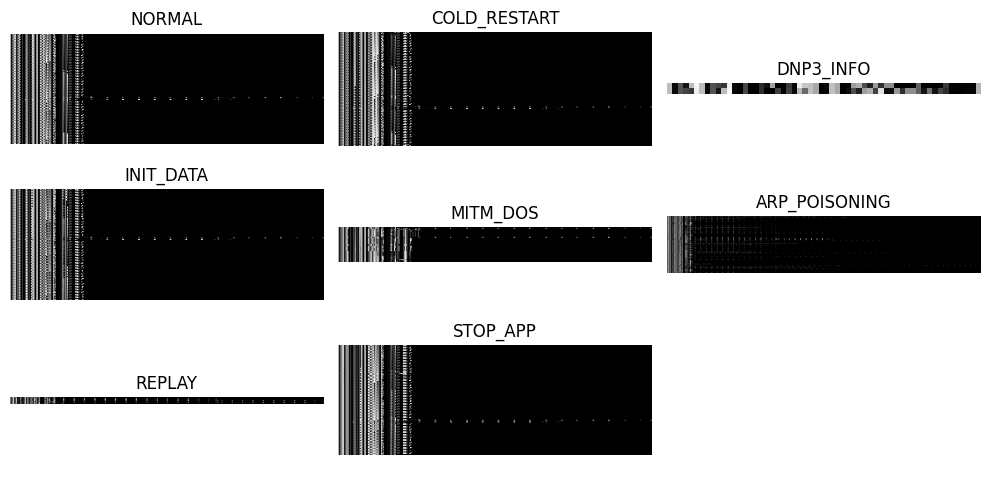

In [66]:
subplot_images(
    images, titles, order=(3, -1), show=False, fig_size=(10, 5), cmap="gray"
).savefig("orig_packets.pdf")

### View Anynomized

In [67]:
from ids_expt.utils.vis import subplot_images

images = []
titles = []
normal_sample = None
for label in extractor.summary_df.Label.unique():
    files = extractor.summary_df.query(f"Label == '{label}'").pcap_file.tolist()
    logger.info(f"Processing label: {label} with {len(files)} files.")
    for file in files:
        packets = extractor.load_pcap(file)
        if not packets:
            # logger.warning(f"No packets found in {file}. Skipping.")
            continue
        session = extractor.make_session(file)
        if session is None:
            logger.warning(f"Session creation failed for {file}. Skipping.")
            continue

        packets = [extractor.anonymize_packet(pkt) for pkt in packets]
        session.packets = packets
        if label == "NORMAL":
            normal_sample = session
        image = extractor.session_to_image(session)
        images.append(image)
        titles.append(label)

        break

2025-06-16 14:34:47.213 | INFO     | __main__:<module>:8 - Processing label: NORMAL with 1639 files.
2025-06-16 14:34:48.075 | INFO     | __main__:<module>:8 - Processing label: COLD_RESTART with 568 files.
2025-06-16 14:34:48.276 | INFO     | __main__:<module>:8 - Processing label: DNP3_INFO with 12 files.
2025-06-16 14:34:48.287 | INFO     | __main__:<module>:8 - Processing label: INIT_DATA with 540 files.
2025-06-16 14:34:48.464 | INFO     | __main__:<module>:8 - Processing label: MITM_DOS with 31 files.
2025-06-16 14:34:48.532 | INFO     | __main__:<module>:8 - Processing label: ARP_POISONING with 39 files.
2025-06-16 14:34:48.804 | INFO     | __main__:<module>:8 - Processing label: REPLAY with 378 files.
2025-06-16 14:34:48.828 | INFO     | __main__:<module>:8 - Processing label: STOP_APP with 540 files.


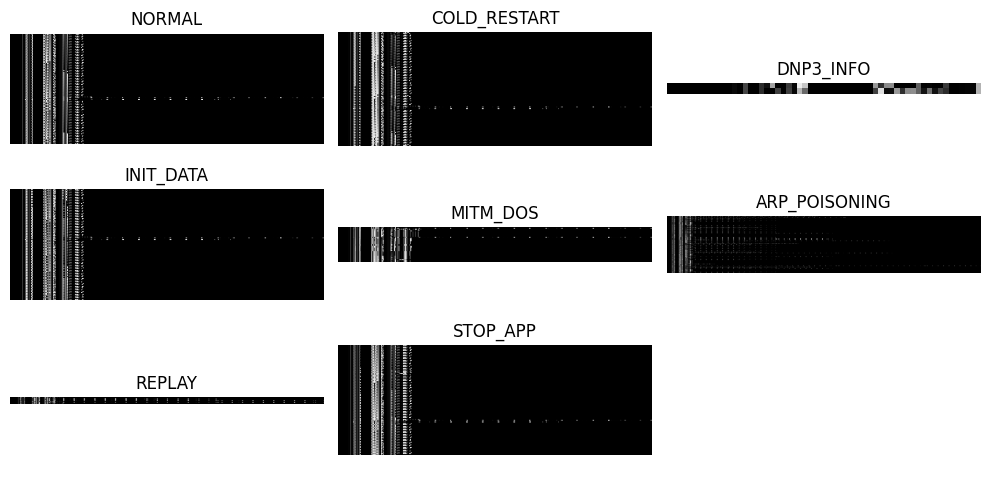

In [68]:
subplot_images(
    images, titles, order=(3, -1), cmap="gray", show=False, fig_size=(10, 5)
).savefig("anonymized_packets.pdf")

In [64]:
normal_sample.packets[0].show()
print(raw(normal_sample.packets[0]))
print(raw(normal_sample.packets[0]).hex())
np.frombuffer(raw(normal_sample.packets[0]), dtype=np.uint8)

###[ Ethernet ]###
  dst       = 00:00:00:00:00:00
  src       = 00:00:00:00:00:00
  type      = IPv4
###[ IP ]###
     version   = 4
     ihl       = 5
     tos       = 0x0
     len       = 70
     id        = 16585
     flags     = DF
     frag      = 0
     ttl       = 64
     proto     = tcp
     chksum    = 0x7692
     src       = 0.0.0.0
     dst       = 0.0.0.0
     \options   \
###[ TCP ]###
        sport     = 0
        dport     = 0
        seq       = 1376557367
        ack       = 3451628063
        dataofs   = 8
        reserved  = 0
        flags     = PA
        window    = 1317
        chksum    = 0xf8fd
        urgptr    = 0
        options   = [('NOP', None), ('NOP', None), ('Timestamp', (20592290, 20590178))]
###[ Raw ]###
           load      = b'\x05d\x0b\xc4\x0c\x00\x01\x00.\xc5\xce\xcd\x01<\x02\x06\x06\xeb'

b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x08\x00E\x00\x00F@\xc9@\x00@\x06v\x92\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00R\x0c\x997\xcd\xbb\xa

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   8,
         0,  69,   0,   0,  70,  64, 201,  64,   0,  64,   6, 118, 146,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  82,
        12, 153,  55, 205, 187, 170,  31, 128,  24,   5,  37, 248, 253,
         0,   0,   1,   1,   8,  10,   1,  58,  54, 162,   1,  58,  46,
        98,   5, 100,  11, 196,  12,   0,   1,   0,  46, 197, 206, 205,
         1,  60,   2,   6,   6, 235], dtype=uint8)